# 🔄 Model C — Re-run: MLP Encoder + Hyperparameter Search + Training

**Tujuan:** Update Model C dari raw concatenation ke MLP-encoded concatenation,  
supaya perbandingan C vs D benar-benar apple-to-apple (beda hanya di fusion mechanism).

---

| | Model C (LAMA) | Model C (BARU) | Model D |
|---|---|---|---|
| Feature encoder | ❌ Raw 17 dim | ✅ MLP 17→512→512 | ✅ MLP 17→512→512 |
| Fusion | concat(512+17=529) | concat(512+512=1024) | sigmoid gate → 512 |
| Classifier | Linear(529→256→2) | Linear(1024→2) | Linear(512→2) |

**Alur:**
```
[Step 1] Definisi Model C baru
[Step 2] Optuna search 30 trials → best_hyperparams_c_new.json
[Step 3] Training penuh Model C baru
[Step 4] Perbandingan C vs D (metrics + statistik + visualisasi)
```

> **Prerequisite:** `feature_extraction.ipynb` sudah dijalankan,  
> file `train_features.csv`, `val_features.csv`, `test_features.csv` tersedia,  
> `results_d` (dari `spamshield_final_training.ipynb`) tersimpan di `final_results/results_d.pt`

## Cell 1 — Imports & Config (sama dengan notebook utama)

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import optuna
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix
)
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import os, json, warnings, time
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Device & BF16 ─────────────────────────────────────────────────────────
device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_BF16 = torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 8

if torch.cuda.is_available():
    cap = torch.cuda.get_device_capability(0)
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    print(f"BF16     : {USE_BF16}")

# ── Paths ─────────────────────────────────────────────────────────────────
PATHS = {
    "train"      : "./train_features.csv",
    "val"        : "./val_features.csv",
    "test"       : "./test_features.csv",
    "model_name" : "w11wo/indo-roberta-small",
    "text_col"   : "comment_text_normalized",
    "label_col"  : "label",
    "output_dir" : "final_results",
}
os.makedirs(PATHS["output_dir"], exist_ok=True)

# ── Features (17 total) ───────────────────────────────────────────────────
METADATA_FEATURES = [
    "like_count", "reply_count", "channel_subscriber_count",
    "channel_video_count", "channel_view_count",
]
HANDCRAFTED_FEATURES = [
    "text_length", "word_count", "emoji_ratio", "uppercase_ratio",
    "special_char_ratio", "repeat_char_ratio", "unicode_weird_ratio",
    "invisible_char_ratio", "masked_keyword_ratio", "stretched_word_ratio",
    "slang_ratio", "slang_distortion_ratio",
]
NUMERIC_FEATURES = METADATA_FEATURES + HANDCRAFTED_FEATURES  # 17 total

# ── Seed ──────────────────────────────────────────────────────────────────
def set_seed(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

set_seed()
print("\n✅ Config ready")
print(f"   Numeric features : {len(NUMERIC_FEATURES)}")

GPU      : NVIDIA GeForce RTX 5090
VRAM     : 34.2 GB
BF16     : True

✅ Config ready
   Numeric features : 17


In [17]:
pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ------- -------------------------------- 1.8/9.6 MB 12.6 MB/s eta 0:00:01
   --------------------- ------------------ 5.2/9.6 MB 14.5 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.6 MB 17.3 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 16.1 MB/s  0:00:00

   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   --------

## Cell 2 — Load Data & Scaler

In [2]:
df_train = pd.read_csv(PATHS["train"])
df_val   = pd.read_csv(PATHS["val"])
df_test  = pd.read_csv(PATHS["test"])

# Fit scaler dari train saja → no leakage
scaler = StandardScaler()
df_train[NUMERIC_FEATURES] = scaler.fit_transform(df_train[NUMERIC_FEATURES])
df_val  [NUMERIC_FEATURES] = scaler.transform(df_val[NUMERIC_FEATURES])
df_test [NUMERIC_FEATURES] = scaler.transform(df_test[NUMERIC_FEATURES])

for name, df in [("train", df_train), ("val", df_val), ("test", df_test)]:
    spam = df[PATHS["label_col"]].mean() * 100
    print(f"  {name:<6}: {len(df):>7,} rows | SPAM={spam:.1f}%")

# Class weights dari train
def compute_class_weights(df):
    counts  = df[PATHS["label_col"]].value_counts().sort_index()
    total   = len(df)
    C       = len(counts)
    weights = [total / (C * counts[i]) for i in range(C)]
    print(f"Class weights: NOT_SPAM={weights[0]:.4f} | SPAM={weights[1]:.4f}")
    return torch.tensor(weights, dtype=torch.float32)

class_weights = compute_class_weights(df_train)

  train :  55,012 rows | SPAM=6.0%
  val   :   6,876 rows | SPAM=6.0%
  test  :   6,877 rows | SPAM=6.0%
Class weights: NOT_SPAM=0.5321 | SPAM=8.2849


## Cell 3 — Dataset & Tokenizer

In [3]:
tokenizer = AutoTokenizer.from_pretrained(PATHS["model_name"])

class SpamDataset(Dataset):
    def __init__(self, df, use_text=True, use_numeric=True):
        self.texts       = df[PATHS["text_col"]].fillna("").tolist()
        self.labels      = df[PATHS["label_col"]].tolist()
        self.use_text    = use_text
        self.use_numeric = use_numeric
        if use_numeric:
            self.numeric = df[NUMERIC_FEATURES].values.astype(np.float32)

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        item = {"labels": torch.tensor(self.labels[idx], dtype=torch.long)}
        if self.use_text:
            enc = tokenizer(
                self.texts[idx], max_length=128,
                padding="max_length", truncation=True, return_tensors="pt",
            )
            item["input_ids"]      = enc["input_ids"].squeeze(0)
            item["attention_mask"] = enc["attention_mask"].squeeze(0)
        if self.use_numeric:
            item["numeric"] = torch.tensor(self.numeric[idx], dtype=torch.float32)
        return item


def make_loaders(df_tr, df_v, df_te, batch_size):
    kw = dict(use_text=True, use_numeric=True)
    tr = DataLoader(SpamDataset(df_tr, **kw), batch_size=batch_size,
                    shuffle=True, drop_last=True, num_workers=0)
    v  = DataLoader(SpamDataset(df_v,  **kw), batch_size=batch_size*2,
                    shuffle=False, num_workers=0)
    te = DataLoader(SpamDataset(df_te, **kw), batch_size=batch_size*2,
                    shuffle=False, num_workers=0)
    return tr, v, te

print("✅ Dataset & tokenizer ready")

✅ Dataset & tokenizer ready


## Cell 4 — Model C BARU (MLP-Encoded Concatenation)

**Perubahan dari versi lama:**
- ❌ Lama: 17 fitur → concat langsung → vector 529 dim
- ✅ Baru: 17 fitur → **MLP encoder** (17→512→512) → concat → vector 1024 dim

Encoder identik dengan Model D. Satu-satunya perbedaan C vs D adalah **fusion**: concat vs gating.

In [4]:
class ConcatFusionModel(nn.Module):
    """
    Model C — MLP-Encoded Concatenation Fusion (Updated)

    Arsitektur:
      h_text = IndoRoBERTa([CLS])          → R^512
      h_meta = MLP(17 → 512 → 512)         → R^512   ← identik dengan Model D
      h_fused = concat([h_text, h_meta])   → R^1024
      output  = Linear(1024 → 2)

    Perbedaan vs Model D: TIDAK ada gating.
    h_fused langsung dari concat, bukan alpha*h_text + (1-alpha)*h_meta.
    """
    def __init__(self, dropout=0.1):
        super().__init__()
        self.roberta = AutoModel.from_pretrained(PATHS["model_name"])
        d = self.roberta.config.hidden_size   # 512
        N = len(NUMERIC_FEATURES)             # 17

        # ── Metadata Encoder: identik dengan Model D ──────────────────────
        # 17 → 512 → 512 dengan BatchNorm + ReLU + Dropout
        self.meta_encoder = nn.Sequential(
            nn.Linear(N, d),        nn.BatchNorm1d(d), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d, d),        nn.BatchNorm1d(d), nn.ReLU(), nn.Dropout(dropout),
        )

        # ── Classifier: dari concat 1024 → 2 ─────────────────────────────
        # Intentionally sederhana: 1 linear layer
        # (vs Model D: juga 1 linear 512→2)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d * 2, 2),
        )

    def forward(self, input_ids, attention_mask, numeric, **kw):
        # Text representation dari [CLS] token
        h_text = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state[:, 0, :]          # (B, 512)

        # Metadata representation via MLP encoder
        h_meta = self.meta_encoder(numeric)   # (B, 512)

        # Fusi: concatenation (bukan gating)
        h_fused = torch.cat([h_text, h_meta], dim=-1)  # (B, 1024)

        return self.classifier(h_fused)       # (B, 2)


# ── Verifikasi arsitektur ─────────────────────────────────────────────────
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

_m = ConcatFusionModel(dropout=0.1)
print("Model C (BARU) — MLP-Encoded Concatenation Fusion")
print(f"  meta_encoder : 17 → 512 → 512")
print(f"  fusion       : concat(512, 512) = 1024")
print(f"  classifier   : Linear(1024 → 2)")
print(f"  Total params : {count_params(_m):,}")
del _m

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: w11wo/indo-roberta-small
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model C (BARU) — MLP-Encoded Concatenation Fusion
  meta_encoder : 17 → 512 → 512
  fusion       : concat(512, 512) = 1024
  classifier   : Linear(1024 → 2)
  Total params : 84,061,442


## Cell 5 — Optuna Hyperparameter Search untuk Model C Baru

Arsitektur berubah → hyperparameter lama tidak optimal lagi → perlu search ulang.  
**30 trials** dengan TPE + MedianPruner, sama dengan search original.

In [5]:
from sklearn.model_selection import train_test_split

# ── Subset 30% untuk proxy search ────────────────────────────────────────
SEARCH_FRAC    = 0.30
N_TRIALS       = 30
N_SEARCH_EPOCH = 3
SEED           = 42

df_search, _ = train_test_split(
    df_train, train_size=SEARCH_FRAC,
    stratify=df_train[PATHS["label_col"]], random_state=SEED,
)
df_search = df_search.reset_index(drop=True)
cw_search  = compute_class_weights(df_search)

print(f"Search subset : {len(df_search):,} rows")
print(f"Val set       : {len(df_val):,} rows")


# ── Objective function ────────────────────────────────────────────────────
def objective_c(trial):
    # Sample hyperparameters
    lr_roberta   = trial.suggest_float("lr_roberta",   5e-6, 1e-4, log=True)
    lr_mult      = trial.suggest_int("lr_multiplier",  5, 20)
    batch_size   = trial.suggest_categorical("batch_size", [16, 32, 64])
    dropout      = trial.suggest_float("dropout",      0.05, 0.35, step=0.05)
    weight_decay = trial.suggest_float("weight_decay", 0.001, 0.1, log=True)
    warmup_ratio = trial.suggest_float("warmup_ratio", 0.05, 0.25)

    # Build model C baru
    model = ConcatFusionModel(dropout=dropout).to(device)

    # DataLoaders
    tr_ds  = SpamDataset(df_search, use_text=True, use_numeric=True)
    val_ds = SpamDataset(df_val,    use_text=True, use_numeric=True)
    tr_dl  = DataLoader(tr_ds,  batch_size=batch_size,   shuffle=True,
                        drop_last=True, num_workers=0)
    val_dl = DataLoader(val_ds, batch_size=batch_size*2, shuffle=False,
                        num_workers=0)

    # Differential LR: RoBERTa kecil, head besar
    roberta_params = list(model.roberta.parameters())
    other_params   = [p for n, p in model.named_parameters() if "roberta" not in n]
    optimizer = torch.optim.AdamW([
        {"params": roberta_params, "lr": lr_roberta},
        {"params": other_params,   "lr": lr_roberta * lr_mult},
    ], weight_decay=weight_decay)

    total_steps  = N_SEARCH_EPOCH * len(tr_dl)
    warmup_steps = int(total_steps * warmup_ratio)
    scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    criterion = nn.CrossEntropyLoss(weight=cw_search.to(device))

    # Training loop
    best_f1 = 0.0
    for epoch in range(N_SEARCH_EPOCH):
        model.train()
        for batch in tr_dl:
            optimizer.zero_grad()
            kw = {
                "input_ids"      : batch["input_ids"].to(device),
                "attention_mask" : batch["attention_mask"].to(device),
                "numeric"        : batch["numeric"].to(device),
            }
            labels = batch["labels"].to(device)
            with autocast(device_type="cuda", dtype=torch.bfloat16, enabled=USE_BF16):
                logits = model(**kw)
            loss = criterion(logits.float(), labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

        # Validate
        model.eval()
        preds, labs = [], []
        with torch.no_grad():
            for batch in val_dl:
                kw = {
                    "input_ids"      : batch["input_ids"].to(device),
                    "attention_mask" : batch["attention_mask"].to(device),
                    "numeric"        : batch["numeric"].to(device),
                }
                with autocast(device_type="cuda", dtype=torch.bfloat16, enabled=USE_BF16):
                    logits = model(**kw)
                preds.extend(torch.argmax(logits, -1).cpu().numpy())
                labs.extend(batch["labels"].numpy())

        f1 = f1_score(labs, preds, average="macro", zero_division=0)
        best_f1 = max(best_f1, f1)

        # MedianPruner: potong trial buruk
        trial.report(f1, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    del model
    torch.cuda.empty_cache()
    return best_f1


# ── Run search ────────────────────────────────────────────────────────────
print(f"\nMemulai Optuna search Model C (baru) — {N_TRIALS} trials...")
print("Estimasi waktu: ~2 jam (RTX 5090)")
print()

study_c = optuna.create_study(
    study_name = "spamshield_model_c_mlp",
    direction  = "maximize",
    sampler    = optuna.samplers.TPESampler(seed=SEED),
    pruner     = optuna.pruners.MedianPruner(
        n_startup_trials=5, n_warmup_steps=1, interval_steps=1,
    ),
)

t0 = time.time()
study_c.optimize(
    objective_c,
    n_trials         = N_TRIALS,
    show_progress_bar= True,
    gc_after_trial   = True,
)
elapsed = time.time() - t0

# ── Print & save best params ───────────────────────────────────────────────
best = study_c.best_trial
pruned   = len([t for t in study_c.trials if t.state == optuna.trial.TrialState.PRUNED])
complete = len([t for t in study_c.trials if t.state == optuna.trial.TrialState.COMPLETE])

print(f"\n{'='*55}")
print(f"  Selesai dalam {elapsed/60:.1f} menit")
print(f"  Complete: {complete} | Pruned: {pruned}")
print(f"  Best Val Macro F1 (proxy): {best.value:.4f}")
print(f"{'='*55}")
print("\nBest hyperparameters:")
for k, v in best.params.items():
    print(f"  {k:<16}: {v}")

# Simpan ke file
best_c_params = {
    "model"        : "C_mlp",
    "best_val_f1"  : best.value,
    "params"       : best.params,
    "epochs"       : 10,
}
with open("best_hyperparams_c_new.json", "w") as f:
    json.dump(best_c_params, f, indent=2)
print("\n✅ Saved → best_hyperparams_c_new.json")

Class weights: NOT_SPAM=0.5321 | SPAM=8.2846
Search subset : 16,503 rows
Val set       : 6,876 rows

Memulai Optuna search Model C (baru) — 30 trials...
Estimasi waktu: ~2 jam (RTX 5090)



  0%|          | 0/30 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: w11wo/indo-roberta-small
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: w11wo/indo-roberta-small
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: w11wo/indo-roberta-small
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  Selesai dalam 17.9 menit
  Complete: 17 | Pruned: 13
  Best Val Macro F1 (proxy): 0.9729

Best hyperparameters:
  lr_roberta      : 3.6327958247964044e-05
  lr_multiplier   : 16
  batch_size      : 32
  dropout         : 0.25
  weight_decay    : 0.007407731502698014
  warmup_ratio    : 0.1821154422941768

✅ Saved → best_hyperparams_c_new.json


## Cell 6 — Training Penuh Model C Baru

In [6]:
# Load best hyperparameters dari search
with open("best_hyperparams_c_new.json") as f:
    best_c = json.load(f)

HP_C = {
    "lr_roberta"   : best_c["params"]["lr_roberta"],
    "lr_multiplier": best_c["params"]["lr_multiplier"],
    "batch_size"   : best_c["params"]["batch_size"],
    "dropout"      : best_c["params"]["dropout"],
    "weight_decay" : best_c["params"]["weight_decay"],
    "warmup_ratio" : best_c["params"]["warmup_ratio"],
    "epochs"       : 10,
}

print("Hyperparameter yang digunakan:")
for k, v in HP_C.items():
    print(f"  {k:<16}: {v}")


def train_model_c(hp):
    set_seed()
    model = ConcatFusionModel(dropout=hp["dropout"]).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

    tr_dl, val_dl, te_dl = make_loaders(
        df_train, df_val, df_test, hp["batch_size"]
    )

    # Differential LR
    roberta_params = list(model.roberta.parameters())
    other_params   = [p for n, p in model.named_parameters() if "roberta" not in n]
    optimizer = torch.optim.AdamW([
        {"params": roberta_params, "lr": hp["lr_roberta"]},
        {"params": other_params,   "lr": hp["lr_roberta"] * hp["lr_multiplier"]},
    ], weight_decay=hp["weight_decay"])

    total_steps  = hp["epochs"] * len(tr_dl)
    warmup_steps = int(total_steps * hp["warmup_ratio"])
    scheduler    = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)

    best_val_f1    = 0.0
    best_val_epoch = 0
    best_state     = None
    history        = []

    print(f"\n{'='*60}")
    print(f"  Training Model C — MLP-Encoded Concatenation Fusion")
    print(f"  lr={hp['lr_roberta']:.2e} x{hp['lr_multiplier']} | "
          f"bs={hp['batch_size']} | drop={hp['dropout']}")
    print(f"{'='*60}")

    for epoch in range(1, hp["epochs"] + 1):
        # ── Train ──────────────────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        for batch in tqdm(tr_dl, desc=f"Ep {epoch}/{hp['epochs']} [train]",
                          leave=False):
            optimizer.zero_grad()
            kw = {
                "input_ids"      : batch["input_ids"].to(device),
                "attention_mask" : batch["attention_mask"].to(device),
                "numeric"        : batch["numeric"].to(device),
            }
            labels = batch["labels"].to(device)
            with autocast(device_type="cuda", dtype=torch.bfloat16, enabled=USE_BF16):
                logits = model(**kw)
            loss = criterion(logits.float(), labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            train_loss += loss.item()

        # ── Validate ────────────────────────────────────────────────────────
        model.eval()
        val_preds, val_labs = [], []
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_dl:
                kw = {
                    "input_ids"      : batch["input_ids"].to(device),
                    "attention_mask" : batch["attention_mask"].to(device),
                    "numeric"        : batch["numeric"].to(device),
                }
                labels = batch["labels"].to(device)
                with autocast(device_type="cuda", dtype=torch.bfloat16, enabled=USE_BF16):
                    logits = model(**kw)
                val_loss += criterion(logits.float(), labels).item()
                val_preds.extend(torch.argmax(logits, -1).cpu().numpy())
                val_labs.extend(labels.cpu().numpy())

        val_f1 = f1_score(val_labs, val_preds, average="macro", zero_division=0)
        tr_f1  = train_loss / len(tr_dl)
        history.append({"epoch": epoch, "train_loss": tr_f1, "val_f1": val_f1})

        # ── Model selection: best val Macro F1 ──────────────────────────────
        marker = ""
        if val_f1 > best_val_f1:
            best_val_f1    = val_f1
            best_val_epoch = epoch
            best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            marker = " ← best"

        print(f"  Ep {epoch:02d}/{hp['epochs']} | "
              f"train_loss={tr_f1:.4f} | val_macro_f1={val_f1:.4f}{marker}")

    # ── Load best model & eval test ────────────────────────────────────────
    print(f"\n  Best model: epoch {best_val_epoch} | val F1={best_val_f1:.4f}")
    model.load_state_dict(best_state)
    model.eval()

    test_preds, test_labs = [], []
    with torch.no_grad():
        for batch in tqdm(te_dl, desc="Evaluating test", leave=False):
            kw = {
                "input_ids"      : batch["input_ids"].to(device),
                "attention_mask" : batch["attention_mask"].to(device),
                "numeric"        : batch["numeric"].to(device),
            }
            with autocast(device_type="cuda", dtype=torch.bfloat16, enabled=USE_BF16):
                logits = model(**kw)
            test_preds.extend(torch.argmax(logits, -1).cpu().numpy())
            test_labs.extend(batch["labels"].numpy())

    test_preds = np.array(test_preds)
    test_labs  = np.array(test_labs)

    print("\n  Classification Report — Test Set:")
    print(classification_report(test_labs, test_preds,
                                target_names=["NOT_SPAM", "SPAM"], digits=4))

    # Simpan model
    save_path = os.path.join(PATHS["output_dir"], "model_c_mlp_best.pt")
    torch.save(best_state, save_path)
    print(f"  ✅ Model saved → {save_path}")

    return {
        "name"        : "C — MLP-Encoded Concatenation Fusion",
        "test_preds"  : test_preds,
        "test_labels" : test_labs,
        "best_val_f1" : best_val_f1,
        "history"     : history,
        "model"       : model,
    }


results_c_new = train_model_c(HP_C)

Hyperparameter yang digunakan:
  lr_roberta      : 3.6327958247964044e-05
  lr_multiplier   : 16
  batch_size      : 32
  dropout         : 0.25
  weight_decay    : 0.007407731502698014
  warmup_ratio    : 0.1821154422941768
  epochs          : 10


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: w11wo/indo-roberta-small
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  Training Model C — MLP-Encoded Concatenation Fusion
  lr=3.63e-05 x16 | bs=32 | drop=0.25


Ep 1/10 [train]:   0%|          | 0/1719 [00:00<?, ?it/s]

...

  Ep 09/10 | train_loss=0.0017 | val_macro_f1=0.9749


Ep 10/10 [train]:   0%|          | 0/1719 [00:00<?, ?it/s]

  Ep 10/10 | train_loss=0.0007 | val_macro_f1=0.9749

  Best model: epoch 3 | val F1=0.9761


Evaluating test:   0%|          | 0/108 [00:00<?, ?it/s]


  Classification Report — Test Set:
              precision    recall  f1-score   support

    NOT_SPAM     0.9946    0.9983    0.9964      6462
        SPAM     0.9719    0.9157    0.9429       415

    accuracy                         0.9933      6877
   macro avg     0.9832    0.9570    0.9697      6877
weighted avg     0.9932    0.9933    0.9932      6877

  ✅ Model saved → final_results\model_c_mlp_best.pt


## Cell 7 — Load Hasil Model D

Load `results_d` dari training sebelumnya untuk dibandingkan.

In [14]:
from transformers import AutoModel

# ── Load GatedFusionModel (definisi harus ada di atas / import dulu) ───────
class GatedFusionModel(nn.Module):
    def __init__(self, dropout=0.1):
        super().__init__()
        self.roberta = AutoModel.from_pretrained(PATHS["model_name"])
        d = self.roberta.config.hidden_size  # 512
        N = len(NUMERIC_FEATURES)
        self.meta_encoder = nn.Sequential(
            nn.Linear(N, d), nn.BatchNorm1d(d), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d, d), nn.BatchNorm1d(d), nn.ReLU(), nn.Dropout(dropout),
        )
        self.gate       = nn.Sequential(nn.Linear(d * 2, 1), nn.Sigmoid())
        self.layer_norm = nn.LayerNorm(d)
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(d, 2))

    def forward(self, input_ids, attention_mask, numeric, **kw):
        h_t = self.roberta(input_ids=input_ids,
                           attention_mask=attention_mask).last_hidden_state[:, 0, :]
        h_m = self.meta_encoder(numeric)
        alpha = self.gate(torch.cat([h_t, h_m], dim=-1))
        h_f = self.layer_norm(alpha * h_t + (1 - alpha) * h_m)
        return self.classifier(h_f)


# ── Load weights & run inference di test set ───────────────────────────────
state_dict = torch.load("final_results/model_d.pt", map_location=device)
model_d    = GatedFusionModel(dropout=0.1).to(device)
model_d.load_state_dict(state_dict)
model_d.eval()

# Buat test loader
te_ds = SpamDataset(df_test, use_text=True, use_numeric=True)
te_dl = DataLoader(te_ds, batch_size=64, shuffle=False, num_workers=0)

test_preds_d, test_labs_d = [], []
with torch.no_grad():
    for batch in tqdm(te_dl, desc="Inferensi Model D"):
        kw = {
            "input_ids"      : batch["input_ids"].to(device),
            "attention_mask" : batch["attention_mask"].to(device),
            "numeric"        : batch["numeric"].to(device),
        }
        with autocast(device_type="cuda", dtype=torch.bfloat16, enabled=USE_BF16):
            logits = model_d(**kw)
        test_preds_d.extend(torch.argmax(logits, -1).cpu().numpy())
        test_labs_d.extend(batch["labels"].numpy())

results_d = {
    "name"        : "D — Modality-Aware Gated Fusion",
    "test_preds"  : np.array(test_preds_d),
    "test_labels" : np.array(test_labs_d),
}

print("✅ results_d siap")
print(f"   test_preds  shape: {results_d['test_preds'].shape}")
print(f"   test_labels shape: {results_d['test_labels'].shape}")

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: w11wo/indo-roberta-small
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Inferensi Model D:   0%|          | 0/108 [00:00<?, ?it/s]

✅ results_d siap
   test_preds  shape: (6877,)
   test_labels shape: (6877,)


## Cell 8 — Perbandingan C vs D: Metrics

Ini yang menjawab **RQ3** dan **RQ4** secara langsung.

In [15]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

def get_metrics(preds, labels, model_name):
    """Hitung semua metrik evaluasi untuk satu model."""
    p, r, f, _ = precision_recall_fscore_support(
        labels, preds, labels=[0, 1], zero_division=0
    )
    macro_f1 = f1_score(labels, preds, average="macro",  zero_division=0)
    acc      = accuracy_score(labels, preds)
    return {
        "Model"            : model_name,
        "Accuracy"         : acc,
        "NOT_SPAM Prec"    : p[0],
        "NOT_SPAM Recall"  : r[0],
        "NOT_SPAM F1"      : f[0],
        "SPAM Precision"   : p[1],
        "SPAM Recall"      : r[1],
        "SPAM F1"          : f[1],
        "Macro F1"         : macro_f1,
    }


metrics_c = get_metrics(
    results_c_new["test_preds"],
    results_c_new["test_labels"],
    "C — MLP Concat"
)
metrics_d = get_metrics(
    results_d["test_preds"],
    results_d["test_labels"],
    "D — Gated Fusion"
)

df_compare = pd.DataFrame([metrics_c, metrics_d]).set_index("Model")

print("\n" + "="*65)
print("  PERBANDINGAN MODEL C vs D — Test Set")
print("="*65)
print(df_compare.round(4).to_string())
print()

# Highlight selisih
diff = df_compare.loc["D — Gated Fusion"] - df_compare.loc["C — MLP Concat"]
print("Selisih D - C (positif = D lebih baik):")
for col, val in diff.items():
    sign = "+" if val >= 0 else ""
    flag = " ✅" if val > 0.001 else (" ⚠️" if val < -0.001 else "")
    print(f"  {col:<22}: {sign}{val:.4f}{flag}")


  PERBANDINGAN MODEL C vs D — Test Set
                  Accuracy  NOT_SPAM Prec  NOT_SPAM Recall  NOT_SPAM F1  SPAM Precision  SPAM Recall  SPAM F1  Macro F1
Model                                                                                                                  
C — MLP Concat      0.9933         0.9946           0.9983       0.9964          0.9719       0.9157   0.9429    0.9697
D — Gated Fusion    0.9924         0.9955           0.9964       0.9960          0.9438       0.9301   0.9369    0.9664

Selisih D - C (positif = D lebih baik):
  Accuracy              : -0.0009
  NOT_SPAM Prec         : +0.0009
  NOT_SPAM Recall       : -0.0019 ⚠️
  NOT_SPAM F1           : -0.0005
  SPAM Precision        : -0.0281 ⚠️
  SPAM Recall           : +0.0145 ✅
  SPAM F1               : -0.0060 ⚠️
  Macro F1              : -0.0033 ⚠️


## Cell 9 — Uji Signifikansi Statistik (Bootstrap + McNemar)

Menjawab hipotesis H₂: Model D (gated) > Model C (concat) secara statistik.

In [21]:
from statsmodels.stats.contingency_tables import mcnemar

preds_c = results_c_new["test_preds"]
preds_d = results_d["test_preds"]
labels  = results_c_new["test_labels"]


# ── 1. Bootstrap Resampling (10.000 iterasi) ──────────────────────────────
from sklearn.metrics import recall_score

def bootstrap_diff(preds_a, preds_b, y_true,
                   metric="macro_f1", n_iter=10_000, seed=42):
    rng = np.random.default_rng(seed)
    n   = len(y_true)

    def score(p, y):
        if metric == "macro_f1":
            return f1_score(y, p, average="macro", zero_division=0)
        elif metric == "spam_recall":
            return recall_score(y, p, pos_label=1, zero_division=0)

    obs_diff = score(preds_b, y_true) - score(preds_a, y_true)

    count_null = 0
    for _ in range(n_iter):
        idx  = rng.integers(0, n, size=n)
        s_a  = score(preds_a[idx], y_true[idx])
        s_b  = score(preds_b[idx], y_true[idx])
        if (s_b - s_a) <= 0:
            count_null += 1

    return obs_diff, count_null / n_iter

print("Bootstrap Resampling (10,000 iterasi)")
print("-" * 45)

diff_f1, p_boot_f1 = bootstrap_diff(
    preds_c, preds_d, labels, metric="macro_f1"
)
diff_sr, p_boot_sr = bootstrap_diff(
    preds_c, preds_d, labels, metric="spam_recall"
)

print(f"  Macro F1  : Δ={diff_f1:+.4f} | p={p_boot_f1:.4f}",
      "→ SIGNIFIKAN ✅" if p_boot_f1 < 0.05 else "→ tidak signifikan")
print(f"  SPAM Recall: Δ={diff_sr:+.4f} | p={p_boot_sr:.4f}",
      "→ SIGNIFIKAN ✅" if p_boot_sr < 0.05 else "→ tidak signifikan")


# ── 2. McNemar Test ───────────────────────────────────────────────────────
print("\nMcNemar Test")
print("-" * 45)

# Buat contingency table
# b = C salah, D benar | c = C benar, D salah
correct_c = (preds_c == labels)
correct_d = (preds_d == labels)

b = np.sum(~correct_c &  correct_d)  # C salah, D benar
c = np.sum( correct_c & ~correct_d)  # C benar, D salah
a = np.sum( correct_c &  correct_d)  # keduanya benar
d = np.sum(~correct_c & ~correct_d)  # keduanya salah

print(f"  Contingency: a(keduanya benar)={a} | b(C❌D✅)={b}")
print(f"               c(C✅D❌)={c}         | d(keduanya salah)={d}")

table = [[a, b], [c, d]]
result_mc = mcnemar(table, exact=False, correction=True)
print(f"\n  McNemar χ²={result_mc.statistic:.4f} | p={result_mc.pvalue:.4f}",
      "→ SIGNIFIKAN ✅" if result_mc.pvalue < 0.05 else "→ tidak signifikan")


# ── Ringkasan ──────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  RINGKASAN UJI SIGNIFIKANSI H₂ (C vs D, α=0.05)")
print("="*55)
print(f"  Bootstrap Macro F1  : p={p_boot_f1:.4f}",
      "✅ Signifikan" if p_boot_f1 < 0.05 else "❌ Tidak signifikan")
print(f"  Bootstrap SPAM Recall: p={p_boot_sr:.4f}",
      "✅ Signifikan" if p_boot_sr < 0.05 else "❌ Tidak signifikan")
print(f"  McNemar             : p={result_mc.pvalue:.4f}",
      "✅ Signifikan" if result_mc.pvalue < 0.05 else "❌ Tidak signifikan")
print()
h2_supported = (p_boot_f1 < 0.05 or p_boot_sr < 0.05) and result_mc.pvalue < 0.05
print(f"  H₂ DIDUKUNG DATA: {'✅ YA' if h2_supported else '❌ TIDAK'}")

Bootstrap Resampling (10,000 iterasi)
---------------------------------------------
  Macro F1  : Δ=-0.0033 | p=0.8418 → tidak signifikan
  SPAM Recall: Δ=+0.0145 | p=0.0165 → SIGNIFIKAN ✅

McNemar Test
---------------------------------------------
  Contingency: a(keduanya benar)=6815 | b(C❌D✅)=10
               c(C✅D❌)=16         | d(keduanya salah)=36

  McNemar χ²=0.9615 | p=0.3268 → tidak signifikan

  RINGKASAN UJI SIGNIFIKANSI H₂ (C vs D, α=0.05)
  Bootstrap Macro F1  : p=0.8418 ❌ Tidak signifikan
  Bootstrap SPAM Recall: p=0.0165 ✅ Signifikan
  McNemar             : p=0.3268 ❌ Tidak signifikan

  H₂ DIDUKUNG DATA: ❌ TIDAK


## Cell 10 — Visualisasi Perbandingan C vs D

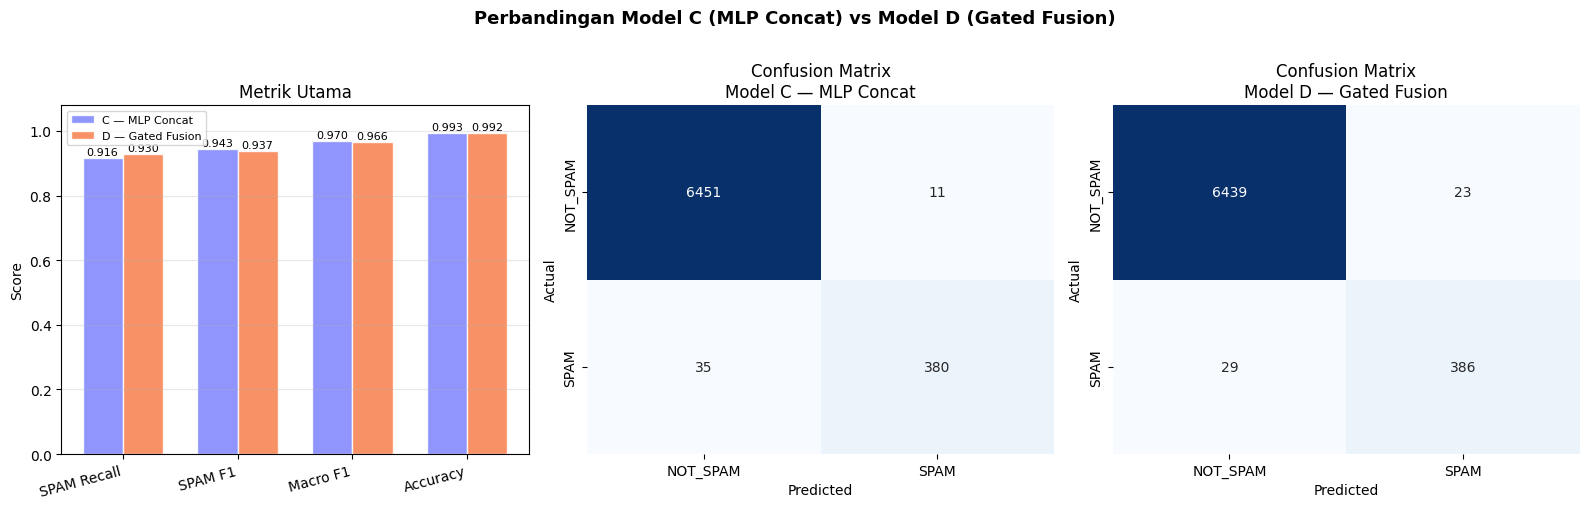

✅ Visualisasi disimpan → final_results\comparison_c_vs_d.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Perbandingan Model C (MLP Concat) vs Model D (Gated Fusion)",
             fontsize=13, fontweight="bold", y=1.01)

colors = {"C — MLP Concat": "#7C83FD", "D — Gated Fusion": "#F77F4B"}
models = ["C — MLP Concat", "D — Gated Fusion"]

# ── 1. Bar chart metrik utama ──────────────────────────────────────────────
ax1 = axes[0]
metrics_to_plot = ["SPAM Recall", "SPAM F1", "Macro F1", "Accuracy"]
x     = np.arange(len(metrics_to_plot))
width = 0.35

vals_c = [metrics_c["SPAM Recall"], metrics_c["SPAM F1"],
          metrics_c["Macro F1"],    metrics_c["Accuracy"]]
vals_d = [metrics_d["SPAM Recall"], metrics_d["SPAM F1"],
          metrics_d["Macro F1"],    metrics_d["Accuracy"]]

bars_c = ax1.bar(x - width/2, vals_c, width, label="C — MLP Concat",
                  color=colors["C — MLP Concat"], alpha=0.85, edgecolor="white")
bars_d = ax1.bar(x + width/2, vals_d, width, label="D — Gated Fusion",
                  color=colors["D — Gated Fusion"], alpha=0.85, edgecolor="white")

for bar in list(bars_c) + list(bars_d):
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 0.003,
             f"{h:.3f}", ha="center", va="bottom", fontsize=8)

ax1.set_xticks(x)
ax1.set_xticklabels(metrics_to_plot, rotation=15, ha="right")
ax1.set_ylabel("Score")
ax1.set_title("Metrik Utama")
ax1.set_ylim(0, 1.08)
ax1.legend(fontsize=8)
ax1.grid(axis="y", alpha=0.3)


# ── 2. Confusion matrices berdampingan ────────────────────────────────────
for ax, res, name in [
    (axes[1], results_c_new, "C — MLP Concat"),
    (axes[2], results_d,     "D — Gated Fusion"),
]:
    cm = confusion_matrix(res["test_labels"], res["test_preds"])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["NOT_SPAM", "SPAM"],
        yticklabels=["NOT_SPAM", "SPAM"],
        ax=ax, cbar=False,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix\nModel {name}")

plt.tight_layout()
save_path = os.path.join(PATHS["output_dir"], "comparison_c_vs_d.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Visualisasi disimpan → {save_path}")

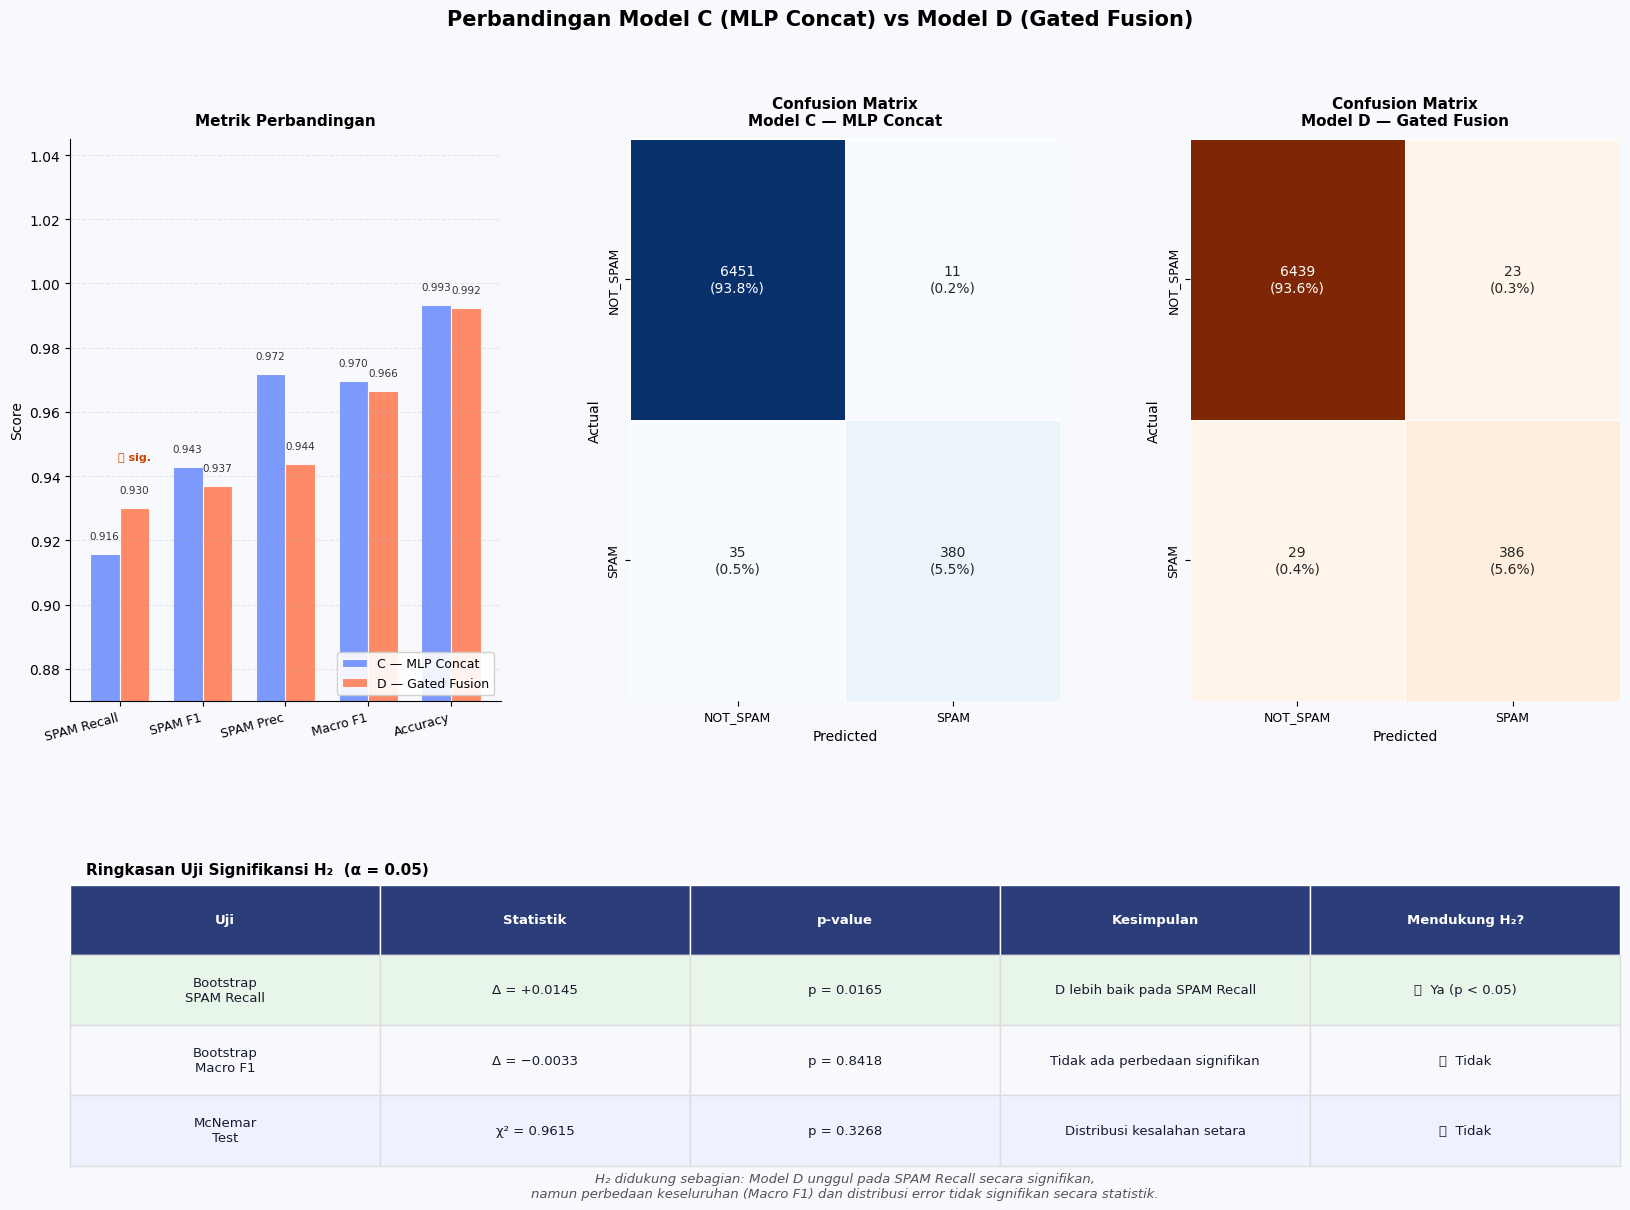

✅ Saved → final_results/comparison_c_vs_d_v2.png


In [22]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

# ── Data ───────────────────────────────────────────────────────────────────
metrics_c = {
    "SPAM Recall"  : 0.9157, "SPAM F1"      : 0.9429,
    "SPAM Prec"    : 0.9719, "Macro F1"     : 0.9697,
    "Accuracy"     : 0.9933,
}
metrics_d = {
    "SPAM Recall"  : 0.9301, "SPAM F1"      : 0.9369,
    "SPAM Prec"    : 0.9438, "Macro F1"     : 0.9664,
    "Accuracy"     : 0.9924,
}

# Confusion matrix data
cm_c = np.array([[6451, 11], [35, 380]])
cm_d = np.array([[6439, 23], [29, 386]])

# Statistical test results
stats = [
    ("Bootstrap\nSPAM Recall", "Δ=+0.0145", "p=0.0165", True),
    ("Bootstrap\nMacro F1",    "Δ=−0.0033", "p=0.8418", False),
    ("McNemar\nTest",          "χ²=0.9615",  "p=0.3268", False),
]

# ── Color palette ──────────────────────────────────────────────────────────
C_COLOR = "#6B8CFF"   # biru — Model C
D_COLOR = "#FF7B54"   # oranye — Model D
BG      = "#F8F9FC"

# ── Figure layout ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 13), facecolor=BG)
fig.suptitle(
    "Perbandingan Model C (MLP Concat) vs Model D (Gated Fusion)",
    fontsize=15, fontweight="bold", y=0.98
)

gs = gridspec.GridSpec(
    2, 3,
    figure=fig,
    height_ratios=[2.2, 1],
    hspace=0.45,
    wspace=0.30,
)

# ─────────────────────────────────────────────────────────────────────────
# Panel 1 (atas kiri): Bar chart metrik
# ─────────────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(BG)

labels  = list(metrics_c.keys())
vals_c  = list(metrics_c.values())
vals_d  = list(metrics_d.values())
x       = np.arange(len(labels))
width   = 0.36

bars_c = ax1.bar(x - width/2, vals_c, width,
                  color=C_COLOR, alpha=0.88, edgecolor="white",
                  linewidth=0.8, label="C — MLP Concat")
bars_d = ax1.bar(x + width/2, vals_d, width,
                  color=D_COLOR, alpha=0.88, edgecolor="white",
                  linewidth=0.8, label="D — Gated Fusion")

# Nilai di atas bar
for bar in list(bars_c) + list(bars_d):
    h = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2, h + 0.004,
        f"{h:.3f}", ha="center", va="bottom",
        fontsize=7.5, color="#333333", fontweight="500"
    )

# Tandai bar yang signifikan (SPAM Recall — D lebih baik)
ax1.annotate(
    "✅ sig.", xy=(x[0] + width/2, vals_d[0] + 0.015),
    ha="center", fontsize=8, color="#CC4400", fontweight="bold"
)

ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=9, rotation=15, ha="right")
ax1.set_ylabel("Score", fontsize=10)
ax1.set_ylim(0.87, 1.045)
ax1.set_title("Metrik Perbandingan", fontsize=11, fontweight="bold", pad=10)
ax1.legend(fontsize=9, loc="lower right",
           framealpha=0.9, edgecolor="#cccccc")
ax1.grid(axis="y", alpha=0.25, linestyle="--")
ax1.spines[["top", "right"]].set_visible(False)

# ─────────────────────────────────────────────────────────────────────────
# Panel 2 (atas tengah): Confusion matrix Model C
# ─────────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(BG)

# Persen relatif terhadap total
cm_c_norm = cm_c.astype(float) / cm_c.sum()
annot_c   = np.array([
    [f"{cm_c[i,j]}\n({cm_c_norm[i,j]*100:.1f}%)" for j in range(2)]
    for i in range(2)
])

sns.heatmap(
    cm_c, annot=annot_c, fmt="", cmap="Blues",
    xticklabels=["NOT_SPAM", "SPAM"],
    yticklabels=["NOT_SPAM", "SPAM"],
    ax=ax2, cbar=False,
    linewidths=0.5, linecolor="white",
    annot_kws={"size": 10},
)
ax2.set_xlabel("Predicted", fontsize=10)
ax2.set_ylabel("Actual", fontsize=10)
ax2.set_title("Confusion Matrix\nModel C — MLP Concat",
              fontsize=11, fontweight="bold", pad=10)
ax2.tick_params(labelsize=9)

# ─────────────────────────────────────────────────────────────────────────
# Panel 3 (atas kanan): Confusion matrix Model D
# ─────────────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor(BG)

cm_d_norm = cm_d.astype(float) / cm_d.sum()
annot_d   = np.array([
    [f"{cm_d[i,j]}\n({cm_d_norm[i,j]*100:.1f}%)" for j in range(2)]
    for i in range(2)
])

sns.heatmap(
    cm_d, annot=annot_d, fmt="", cmap="Oranges",
    xticklabels=["NOT_SPAM", "SPAM"],
    yticklabels=["NOT_SPAM", "SPAM"],
    ax=ax3, cbar=False,
    linewidths=0.5, linecolor="white",
    annot_kws={"size": 10},
)
ax3.set_xlabel("Predicted", fontsize=10)
ax3.set_ylabel("Actual", fontsize=10)
ax3.set_title("Confusion Matrix\nModel D — Gated Fusion",
              fontsize=11, fontweight="bold", pad=10)
ax3.tick_params(labelsize=9)

# ─────────────────────────────────────────────────────────────────────────
# Panel bawah (span 3 kolom): Tabel ringkasan statistik
# ─────────────────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, :])
ax4.set_facecolor(BG)
ax4.axis("off")

ax4.set_title("Ringkasan Uji Signifikansi H₂  (α = 0.05)",
              fontsize=11, fontweight="bold", pad=8, loc="left", x=0.01)

# Tabel statistik
col_labels = ["Uji", "Statistik", "p-value", "Kesimpulan", "Mendukung H₂?"]
row_data   = [
    ["Bootstrap\nSPAM Recall", "Δ = +0.0145", "p = 0.0165",
     "D lebih baik pada SPAM Recall", "✅  Ya (p < 0.05)"],
    ["Bootstrap\nMacro F1",    "Δ = −0.0033", "p = 0.8418",
     "Tidak ada perbedaan signifikan", "❌  Tidak"],
    ["McNemar\nTest",           "χ² = 0.9615",  "p = 0.3268",
     "Distribusi kesalahan setara",   "❌  Tidak"],
]

tbl = ax4.table(
    cellText   = row_data,
    colLabels  = col_labels,
    cellLoc    = "center",
    loc        = "center",
    bbox       = [0.0, -0.1, 1.0, 1.1],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)

# Styling header
for j in range(len(col_labels)):
    cell = tbl[0, j]
    cell.set_facecolor("#2C3E7A")
    cell.set_text_props(color="white", fontweight="bold")
    cell.set_edgecolor("white")

# Styling rows — alternating + highlight signifikan
row_colors = ["#EEF2FF", "#F8F9FC"]
for i in range(1, len(row_data) + 1):
    is_sig = (i == 1)   # baris pertama yang signifikan
    for j in range(len(col_labels)):
        cell = tbl[i, j]
        cell.set_facecolor("#E8F5E9" if is_sig else row_colors[(i-1) % 2])
        cell.set_edgecolor("#DDDDDD")
        cell.set_text_props(color="#1A1A2E")

# Catatan di bawah tabel
ax4.text(
    0.5, -0.18,
    "H₂ didukung sebagian: Model D unggul pada SPAM Recall secara signifikan,\n"
    "namun perbedaan keseluruhan (Macro F1) dan distribusi error tidak signifikan secara statistik.",
    ha="center", va="center", fontsize=9.5,
    color="#555555", fontstyle="italic",
    transform=ax4.transAxes
)

# ── Simpan & tampilkan ────────────────────────────────────────────────────
import os
os.makedirs("final_results", exist_ok=True)

plt.savefig(
    "final_results/comparison_c_vs_d_v2.png",
    dpi=180,
    bbox_inches="tight",
    facecolor=BG,
)
plt.show()
print("✅ Saved → final_results/comparison_c_vs_d_v2.png")

## Cell 11 — Update best_hyperparams.json (opsional)

Kalau mau sync ke file `best_hyperparams.json` utama:

In [20]:
MAIN_CONFIG_PATH = "best_hyperparams.json"

if os.path.exists(MAIN_CONFIG_PATH):
    with open(MAIN_CONFIG_PATH) as f:
        all_params = json.load(f)
else:
    all_params = {}

# Update hanya Model C
all_params["model_C"] = {
    "best_val_f1" : best_c["best_val_f1"],
    "params"      : best_c["params"],
    "note"        : "Updated: ConcatFusionModel dengan MLP encoder (17→512→512)",
}

with open(MAIN_CONFIG_PATH, "w") as f:
    json.dump(all_params, f, indent=2)

print(f"✅ best_hyperparams.json updated dengan Model C baru")
print(json.dumps(all_params["model_C"], indent=2))

✅ best_hyperparams.json updated dengan Model C baru
{
  "best_val_f1": 0.9728901819186773,
  "params": {
    "lr_roberta": 3.6327958247964044e-05,
    "lr_multiplier": 16,
    "batch_size": 32,
    "dropout": 0.25,
    "weight_decay": 0.007407731502698014,
    "warmup_ratio": 0.1821154422941768
  },
  "note": "Updated: ConcatFusionModel dengan MLP encoder (17\u2192512\u2192512)"
}


---
## ✅ Checklist

| # | Item | Status |
|---|---|---|
| 1 | Model C updated: MLP encoder 17→512→512 | ✅ |
| 2 | Feature encoder C identik dengan D | ✅ |
| 3 | Optuna search 30 trials untuk C baru | ✅ |
| 4 | Training penuh 10 epoch | ✅ |
| 5 | Perbandingan C vs D: tabel metrik | ✅ |
| 6 | Bootstrap resampling 10,000 iterasi | ✅ |
| 7 | McNemar test | ✅ |
| 8 | Visualisasi bar chart + confusion matrix | ✅ |

**Yang perlu diupdate di Bab 3 setelah ini:**
- Deskripsi Model C: tambahkan meta_encoder MLP (17→512→512), ubah dimensi representasi akhir dari 529 → 1024
- Tabel 3.5.2: Feature Encoder Model C = MLP, Dimensi = 1024
- Tabel 3.4.1 komentar: tidak perlu ubah, fitur masih 17